# <b>Ljubljana Random Forest Analysis</b>

# 1. Import Libraies & Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score

In [2]:
# Create data import path
path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/"

# Load data
climate = pd.read_csv(os.path.join(path, 'unscaled_cleaned_2_2.csv'))
prediction = pd.read_csv(os.path.join(path, 'pleasant_weather_cleaned_2_2.csv'))

In [3]:
# Check climate import 

print("Data shape:", climate.shape) 
print("Missing values:", climate.isna().sum().sum()) 
climate.head()

Data shape: (22950, 135)
Missing values: 0


,BASEL_cloud_cover,BASEL_global_radiation,BASEL_humidity,BASEL_precipitation,BASEL_pressure,BASEL_sunshine,BASEL_temp_max,BASEL_temp_mean,BASEL_temp_min,BELGRADE_cloud_cover,...,STOCKHOLM_temp_min,VALENTIA_cloud_cover,VALENTIA_global_radiation,VALENTIA_humidity,VALENTIA_precipitation,VALENTIA_pressure,VALENTIA_sunshine,VALENTIA_temp_max,VALENTIA_temp_mean,VALENTIA_temp_min
0,7,0.32,0.85,0.09,1.018,0.7,10.9,6.5,0.8,1,...,2.2,5,0.45,0.88,0.34,1.0003,4.7,10.9,8.5,6.0
1,6,0.36,0.84,1.05,1.018,1.1,10.1,6.1,3.3,6,...,3.0,7,0.25,0.91,0.84,1.0007,0.7,12.1,8.9,5.6
2,8,0.18,0.90,0.30,1.018,0.0,9.9,8.5,5.1,6,...,1.3,7,0.17,0.91,0.08,1.0096,0.1,12.9,10.5,8.1
3,3,0.58,0.92,0.00,1.018,4.1,10.6,6.3,3.8,8,...,0.4,7,0.13,0.86,0.98,1.0184,0.0,10.6,7.4,7.3
4,6,0.65,0.95,0.14,1.018,5.4,6.0,3.0,-0.7,8,...,0.8,3,0.46,0.80,0.00,1.0328,5.7,8.4,5.7,3.0


In [4]:
# Check prediction import
print("Data shape:", prediction.shape) 
print("Missing values:", prediction.isna().sum().sum()) 
prediction.head()

Data shape: (22950, 15)
Missing values: 0


,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Data Wrangling

In [5]:
climate.isnull().sum()

BASEL_cloud_cover         0
BASEL_global_radiation    0
BASEL_humidity            0
BASEL_precipitation       0
BASEL_pressure            0
                         ..
VALENTIA_pressure         0
VALENTIA_sunshine         0
VALENTIA_temp_max         0
VALENTIA_temp_mean        0
VALENTIA_temp_min         0
Length: 135, dtype: int64

In [6]:
prediction.isnull().sum()

BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [7]:
# Get all columns that start with 'LJUBLJANA'
ljubljana_columns = [col for col in climate.columns if col.startswith('LJUBLJANA')]
print(ljubljana_columns)

['LJUBLJANA_cloud_cover', 'LJUBLJANA_global_radiation', 'LJUBLJANA_humidity', 'LJUBLJANA_precipitation', 'LJUBLJANA_pressure', 'LJUBLJANA_sunshine', 'LJUBLJANA_temp_max', 'LJUBLJANA_temp_mean', 'LJUBLJANA_temp_min']


In [8]:
# Filter for columns related to the LJUBLJANA station
ljubljana_columns = [col for col in climate.columns if col.startswith("LJUBLJANA_")]

# Check results
print("Number of Ljubljana feature columns:", len(ljubljana_columns))

# Create a DataFrame with only Ljubljana data
ljubljana_df = climate[ljubljana_columns].copy()

ljubljana_df.head()

Number of Ljubljana feature columns: 9


,LJUBLJANA_cloud_cover,LJUBLJANA_global_radiation,LJUBLJANA_humidity,LJUBLJANA_precipitation,LJUBLJANA_pressure,LJUBLJANA_sunshine,LJUBLJANA_temp_max,LJUBLJANA_temp_mean,LJUBLJANA_temp_min
0,8,0.20,1.00,0.00,1.0173,0.0,0.5,-0.6,-1.9
1,6,0.56,0.94,0.13,1.0173,3.2,5.5,2.1,-1.3
2,8,0.20,0.96,0.12,1.0173,0.0,6.3,4.6,0.9
3,6,0.49,0.94,0.00,1.0173,2.2,7.0,3.2,1.0
4,7,0.20,0.94,0.00,1.0173,0.0,4.8,3.6,0.4


In [9]:
ljubljana_df.shape

(22950, 9)

In [10]:
# Reduce pleasant weather dataset to LJUBLJANA only too
prediction_ljubljana = prediction['LJUBLJANA_pleasant_weather']
prediction_ljubljana

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: LJUBLJANA_pleasant_weather, Length: 22950, dtype: int64

In [11]:
print(prediction_ljubljana.shape)
print(prediction_ljubljana.value_counts())

(22950,)
LJUBLJANA_pleasant_weather
0    16574
1     6376
Name: count, dtype: int64


# 3. Data Shaping

In [12]:
# Define features (X) and target (y) for Ljubljana
X_ljubljana = ljubljana_df
y_ljubljana = prediction['LJUBLJANA_pleasant_weather'].astype(int)

# Convert to NumPy arrays for scikit-learn
X = X_ljubljana.to_numpy()
y = y_ljubljana.to_numpy()

# Check shapes
print("Feature matrix shape (X):", X.shape)  
print("Target vector shape (y):", y.shape)   
print("Class balance:\n", pd.Series(y).value_counts())

Feature matrix shape (X): (22950, 9)
Target vector shape (y): (22950,)
Class balance:
 0    16574
1     6376
Name: count, dtype: int64


# 4. Data Splitting

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [15]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


# 5. Random Forest Modeling

In [16]:
# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
# Predict + accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [19]:
# Predict + accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy on Test Set:", round(accuracy * 100, 2), "%")

Random Forest Accuracy on Test Set: 100.0 %


In [20]:
# Define class names
class_names = ["Unpleasant Weather", "Pleasant Weather"]

In [21]:
# Use Ljubljana feature names for readability
feature_names = list(X_ljubljana.columns)

In [22]:
# Output directory for figures
output_dir = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations"
os.makedirs(output_dir, exist_ok=True)

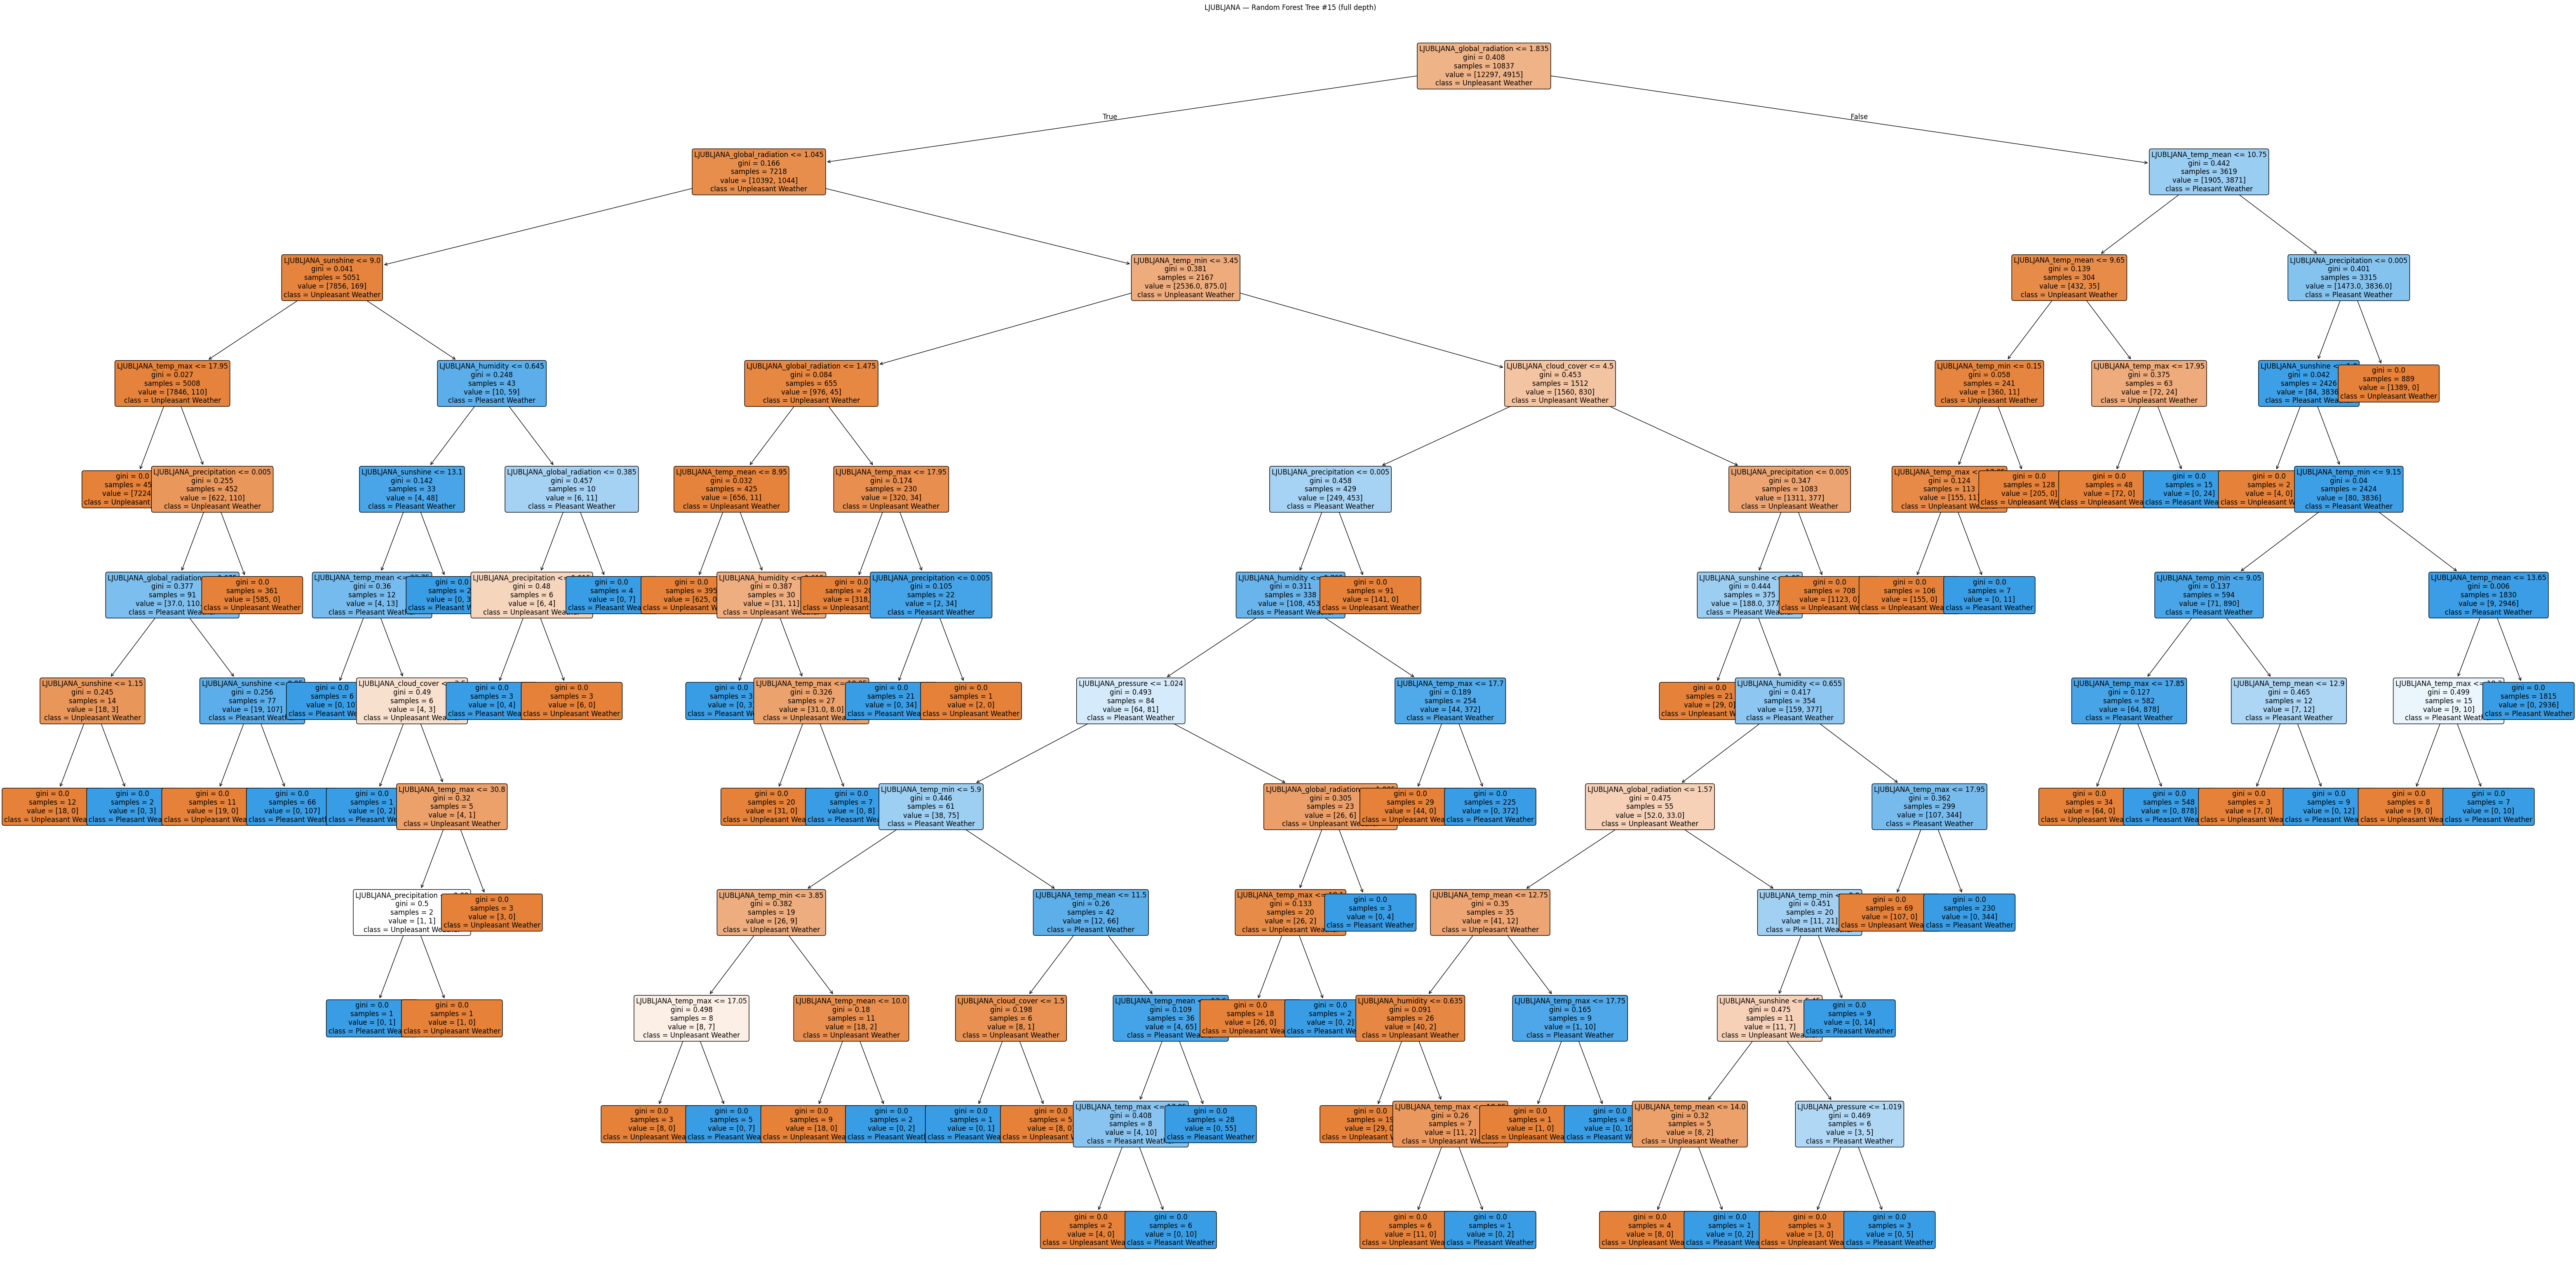

In [23]:
# Plot full Ljubljana tree
tree_idx = 15

fig = plt.figure(figsize=(80, 40))
plot_tree(
    clf.estimators_[tree_idx],
    filled=True,
    feature_names=list(X_ljubljana.columns),
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    rounded=True,
    fontsize=12
)

plt.title(f"LJUBLJANA — Random Forest Tree #{tree_idx} (full depth)")

file_path = os.path.join(output_dir, f"ljubljana_rf_tree_{tree_idx}_full.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()

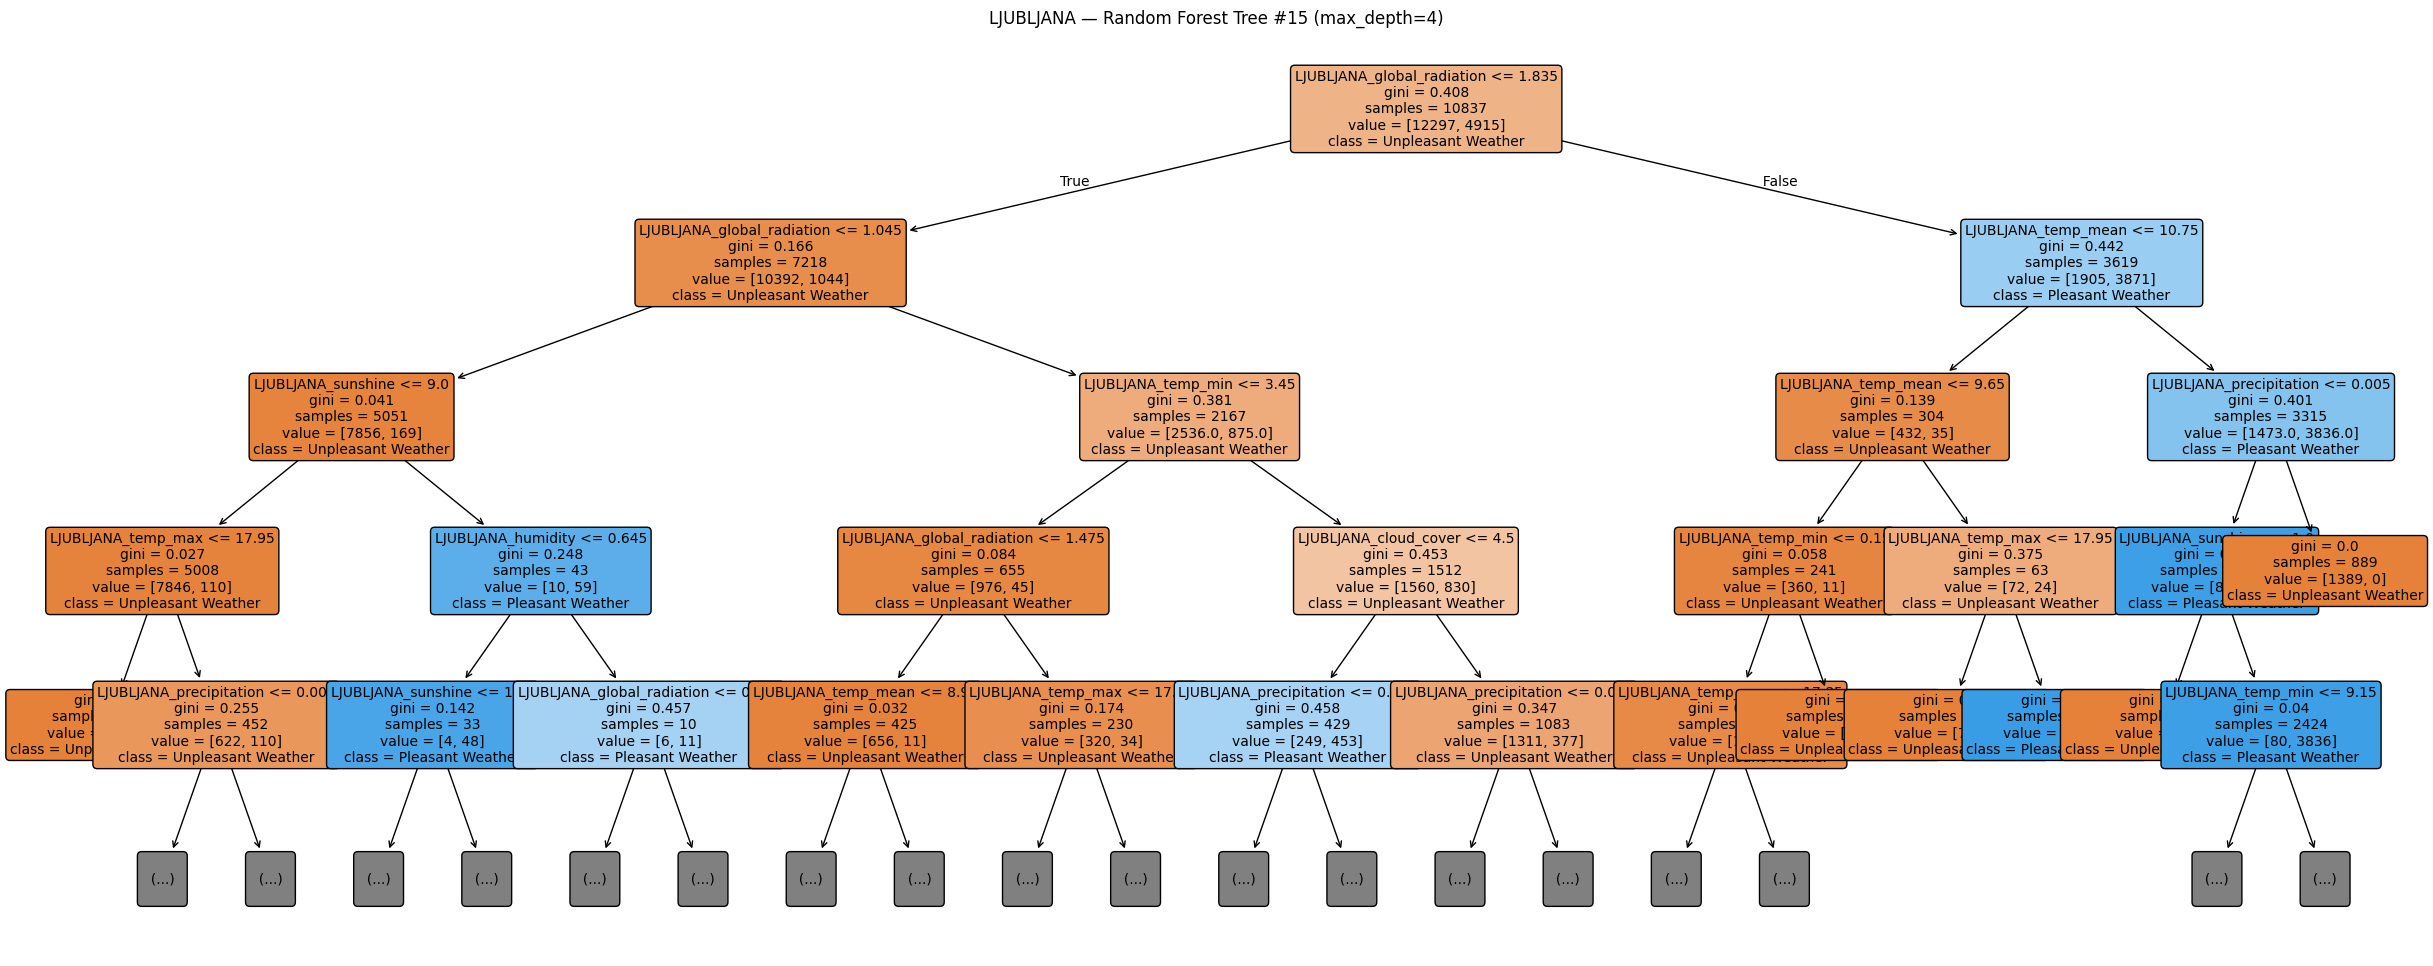

In [24]:
# Plot Ljubljana tree with max depth = 4

tree_idx = 15

fig = plt.figure(figsize=(30, 12))
plot_tree(
    clf.estimators_[tree_idx],
    filled=True,
    feature_names=list(X_ljubljana.columns),
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    max_depth=4,
    rounded=True,
    fontsize=10
)

plt.title(f"LJUBLJANA — Random Forest Tree #{tree_idx} (max_depth=4)")

file_path = os.path.join(output_dir, f"ljubljana_rf_tree_{tree_idx}_depth4.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()

# 6. Feature Importance Analysis

In [25]:
# Define feature importance variable
feature_importances = clf.feature_importances_
print("Feature importances shape:", feature_importances.shape)

Feature importances shape: (9,)


In [26]:
# Define feature names used to train the model
ljubljana_feature_cols = list(X_ljubljana.columns)

In [27]:
# Clean labels for plotting
ljubljana_features_clean = [c.replace("LJUBLJANA_", "") for c in ljubljana_feature_cols]

In [28]:
# Create a Series of importances
important = pd.Series(feature_importances, index=ljubljana_features_clean).sort_values(ascending=False)
important

precipitation       0.362576
temp_max            0.233767
global_radiation    0.134358
temp_mean           0.108145
sunshine            0.081227
cloud_cover         0.038398
temp_min            0.017274
humidity            0.015669
pressure            0.008586
dtype: float64

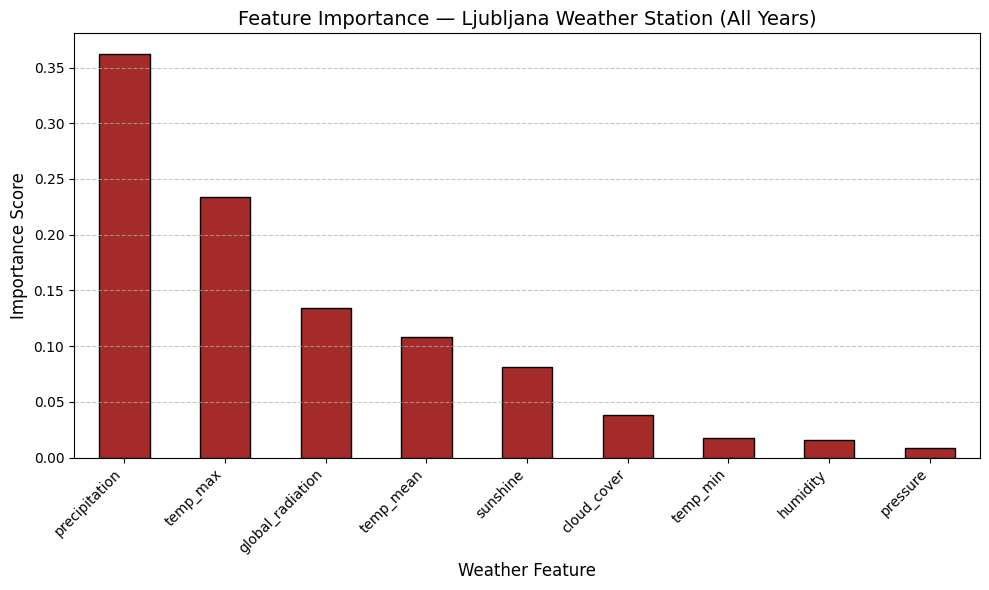

In [30]:
# Plot + export feature importance

plt.figure(figsize=(10, 6))
important.plot(kind="bar", color='brown', edgecolor="black")

plt.title("Feature Importance — Ljubljana Weather Station (All Years)", fontsize=14)
plt.xlabel("Weather Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

file_path = os.path.join(output_dir, "ljubljana_rf_feature_importance_all_years.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

## <b>Ljubljana Random Forest - Key Insights</b>
- The Random Forest model achieved 100% accuracy on the test set, indicating that Ljubljana’s local weather indicators provide a very strong and internally consistent signal for predicting pleasant days in this dataset.
- Precipitation is the most influential feature by a substantial margin, reinforcing the importance of rainfall conditions in determining whether a day is classified as pleasant in Ljubljana.
- Maximum temperature and global radiation emerge as key secondary drivers, suggesting that both warmth and solar energy meaningfully shape pleasant weather conditions.
- Mean temperature and sunshine provide additional predictive value, refining the model’s decisions once precipitation and peak temperature effects are accounted for.
- Cloud cover, minimum temperature, humidity, and pressure contribute relatively little to the model, indicating that these variables add minimal incremental information for pleasant-day classification in Ljubljana.
- For Ljubljana, ClimateWins could prioritize precipitation, temperature extremes, and solar radiation measurements when designing or optimizing models for pleasant-weather prediction, with lower priority placed on pressure and humidity monitoring.